In [14]:
from pathlib import Path
import json
import math
import random

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as io
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


SEED = 42
DATA_DIR = Path("/workspace/SURF-2026-me/data")
GRID_SIZE = 128
NUM_BASIS = 12

# 'quick' mode is for quick testing and debugging, 
# while 'full' mode is for full training and evaluation.
RUN_MODE = "full"  # choices: "quick", "full"

QUICK_TRAIN_SIZE = 128
QUICK_VAL_SIZE = 32
QUICK_TEST_SIZE = 16
QUICK_EPOCHS = 2
QUICK_BATCH_SIZE = 8

FULL_TRAIN_SIZE = 3500
FULL_VAL_SIZE = 300
FULL_TEST_SIZE = 100
FULL_EPOCHS = 60
FULL_BATCH_SIZE = 32

TRAIN_SIZE = FULL_TRAIN_SIZE
TEST_SIZE = FULL_TEST_SIZE
BATCH_SIZE = FULL_BATCH_SIZE
EPOCHS = FULL_EPOCHS
GRAD_WEIGHT = 0.1
LEARNING_RATE = 1e-3
SAVE_BEST_MODEL = True

RESULTS_DIR = Path("outputs/teaching_single_basis2_no_attention")
OUTPUT_DIR = RESULTS_DIR
MODEL_DIR = Path("best_model2_no_attention")

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("run mode:", RUN_MODE)


device: cuda
run mode: full


In [15]:
def _read_h5_array(path, key):
    with h5py.File(path, "r") as f:
        arr = f[key][()]
    return arr


def _fix_h5_orientation(arr, leading_dim):
    if arr.shape[0] == leading_dim:
        return np.transpose(arr)
    return arr


def load_pair(data_dir, kappa_name, basis_name, grid_size=128, num_basis=12):
    kappa = _read_h5_array(data_dir / kappa_name, "Ks")
    basis = _read_h5_array(data_dir / basis_name, "bfs")

    kappa = _fix_h5_orientation(kappa, leading_dim=1)
    basis = _fix_h5_orientation(basis, leading_dim=num_basis)

    n_samples = kappa.size // (grid_size * grid_size)
    kappa = kappa.reshape(n_samples, 1, grid_size, grid_size).astype(np.float32)
    basis = basis.reshape(n_samples, grid_size * grid_size, num_basis).astype(np.float32)
    return kappa, basis


def load_all_data(data_dir=DATA_DIR, grid_size=GRID_SIZE, num_basis=NUM_BASIS):
    pairs = [
        ("kappa.mat", "basis.mat"),
        ("kappa2.mat", "basis2.mat"),
    ]
    xs, ys = zip(*(load_pair(data_dir, x_name, y_name, grid_size, num_basis) for x_name, y_name in pairs))
    x_all = np.concatenate(xs, axis=0)
    y_all = np.concatenate(ys, axis=0)
    print("x_all:", x_all.shape, "y_all:", y_all.shape)
    return x_all, y_all


In [16]:
class KappaBasisDataset(Dataset):
    def __init__(self, x, y, logk=True, normalize_x=True, x_mean=None, x_std=None):
        x = x.astype(np.float32)
        y = y.astype(np.float32)

        if logk:
            x = np.log10(np.clip(x, 1e-12, None))

        if normalize_x:
            self.x_mean = float(x.mean()) if x_mean is None else float(x_mean)
            self.x_std = float(x.std() + 1e-12) if x_std is None else float(x_std)
            x = (x - self.x_mean) / self.x_std
        else:
            self.x_mean = 0.0
            self.x_std = 1.0

        if y.ndim == 2 and y.shape[1] == GRID_SIZE * GRID_SIZE:
            y = y.reshape(-1, 1, GRID_SIZE, GRID_SIZE)
        elif y.ndim == 3 and y.shape[1:] == (GRID_SIZE, GRID_SIZE):
            y = y[:, None, :, :]
        elif y.ndim == 3 and y.shape[1:] == (GRID_SIZE * GRID_SIZE, 1):
            y = y.squeeze(-1).reshape(-1, 1, GRID_SIZE, GRID_SIZE)
        elif y.ndim == 4 and y.shape[1:] == (1, GRID_SIZE, GRID_SIZE):
            pass
        else:
            raise ValueError(f"Unexpected y shape: {y.shape}")

        self.x = torch.from_numpy(x).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


def make_loaders(
    x_all,
    y_all,
    basis_index,
    train_size=TRAIN_SIZE,
    test_size=TEST_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    logk=True,
):
    """Create train/val/test loaders for one basis function.

    The split is deterministic for a given seed. Training uses train_idx, epoch
    monitoring uses val_idx, and final evaluation/spectral analysis uses the
    100-sample test_idx split out from the original validation pool.
    """
    if not 0 <= basis_index < y_all.shape[-1]:
        raise ValueError(f"basis_index must be in [0, {y_all.shape[-1] - 1}], got {basis_index}")
    if train_size + test_size >= x_all.shape[0]:
        raise ValueError(
            f"train_size + test_size must be smaller than sample count; "
            f"got {train_size} + {test_size} >= {x_all.shape[0]}"
        )

    rng = np.random.default_rng(seed)
    indices = rng.permutation(x_all.shape[0])
    train_idx = indices[:train_size]
    eval_idx = indices[train_size:]
    test_idx = eval_idx[:test_size]
    val_idx = eval_idx[test_size:]

    y_basis = y_all[:, :, basis_index]
    train_dataset = KappaBasisDataset(x_all[train_idx], y_basis[train_idx], logk=logk)

    dataset_kwargs = {
        "logk": logk,
        "x_mean": train_dataset.x_mean,
        "x_std": train_dataset.x_std,
    }
    val_dataset = KappaBasisDataset(x_all[val_idx], y_basis[val_idx], **dataset_kwargs)
    test_dataset = KappaBasisDataset(x_all[test_idx], y_basis[test_idx], **dataset_kwargs)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


In [17]:
def run_sizes(run_mode=RUN_MODE):
    if run_mode == "quick":
        return QUICK_TRAIN_SIZE, QUICK_VAL_SIZE, QUICK_TEST_SIZE, QUICK_BATCH_SIZE, QUICK_EPOCHS
    if run_mode == "full":
        return FULL_TRAIN_SIZE, FULL_VAL_SIZE, FULL_TEST_SIZE, FULL_BATCH_SIZE, FULL_EPOCHS
    raise ValueError("RUN_MODE must be 'quick' or 'full'")


def make_loaders(
    x_all,
    y_all,
    basis_index,
    train_size,
    val_size,
    test_size,
    batch_size,
    seed=SEED,
    logk=True,
):
    """Create train/validation/test loaders for one selected basis function."""
    if not 0 <= basis_index < y_all.shape[-1]:
        raise ValueError(f"basis_index must be in [0, {y_all.shape[-1] - 1}], got {basis_index}")
    needed = train_size + val_size + test_size
    if needed > x_all.shape[0]:
        raise ValueError(f"Requested {needed} samples, but only {x_all.shape[0]} are available")

    rng = np.random.default_rng(seed)
    indices = rng.permutation(x_all.shape[0])
    train_idx = indices[:train_size]
    val_idx = indices[train_size:train_size + val_size]
    test_idx = indices[train_size + val_size:train_size + val_size + test_size]

    y_basis = y_all[:, :, basis_index]
    train_dataset = KappaBasisDataset(x_all[train_idx], y_basis[train_idx], logk=logk)
    dataset_kwargs = {"logk": logk, "x_mean": train_dataset.x_mean, "x_std": train_dataset.x_std}
    val_dataset = KappaBasisDataset(x_all[val_idx], y_basis[val_idx], **dataset_kwargs)
    test_dataset = KappaBasisDataset(x_all[test_idx], y_basis[test_idx], **dataset_kwargs)

    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
        DataLoader(val_dataset, batch_size=batch_size, shuffle=False),
        DataLoader(test_dataset, batch_size=batch_size, shuffle=False),
    )


In [18]:
def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def as_field_batch(x):
    """Convert (H,W), (N,H,W), or (N,1,H,W) into (N,H,W)."""
    arr = _to_numpy(x).astype(np.float64, copy=False)
    if arr.ndim == 2:
        return arr[None, :, :]
    if arr.ndim == 3:
        return arr
    if arr.ndim == 4 and arr.shape[1] == 1:
        return arr[:, 0, :, :]
    if arr.ndim == 4 and arr.shape[-1] == 1:
        return arr[..., 0]
    raise ValueError(f"Unexpected field shape: {arr.shape}")


def basis_raw_to_physical_field(field, coarse_shape=(32, 32), local_shape=(4, 4)):
    """Rebuild the physical 128x128 field from coarse-cell ordered basis values."""
    arr = _to_numpy(field).astype(np.float64, copy=False)
    if arr.ndim == 2 and arr.shape == (coarse_shape[0] * local_shape[0], coarse_shape[1] * local_shape[1]):
        arr = arr.reshape(-1)
    if arr.ndim != 1:
        raise ValueError(f"Expected one flattened or 2D basis field, got {arr.shape}")
    expected = coarse_shape[0] * coarse_shape[1] * local_shape[0] * local_shape[1]
    if arr.size != expected:
        raise ValueError(f"Expected {expected} values, got {arr.size}")
    blocks = arr.reshape(coarse_shape[0], coarse_shape[1], local_shape[0], local_shape[1])
    return blocks.transpose(0, 2, 1, 3).reshape(coarse_shape[0] * local_shape[0], coarse_shape[1] * local_shape[1])


def as_physical_field_batch(x, coarse_shape=(32, 32), local_shape=(4, 4)):
    """Convert model/target basis output to physical (N,128,128) fields for spectral analysis."""
    raw = as_field_batch(x)
    return np.stack([
        basis_raw_to_physical_field(field, coarse_shape=coarse_shape, local_shape=local_shape)
        for field in raw
    ], axis=0)


def coarse_element_patch(field, coarse_elem_idx, local_shape=(4, 4), one_based=True):
    """Extract one 4x4 local basis patch from the raw coarse-cell ordered output."""
    arr = as_field_batch(field)[0].reshape(-1)
    idx = coarse_elem_idx - 1 if one_based else coarse_elem_idx
    patch_size = local_shape[0] * local_shape[1]
    start = idx * patch_size
    end = start + patch_size
    if start < 0 or end > arr.size:
        raise IndexError(f"coarse_elem_idx={coarse_elem_idx} is outside 1..{arr.size // patch_size}")
    return arr[start:end].reshape(local_shape)


def batch_r2_score(pred, target, eps=1e-12):
    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)
    ss_res = ((target - pred) ** 2).sum(dim=1)
    ss_tot = ((target - target.mean(dim=1, keepdim=True)) ** 2).sum(dim=1)
    return (1.0 - ss_res / (ss_tot + eps)).mean().item()


def gradient_mse_eval(pred, target):
    dx_pred = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    dy_pred = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    dx_true = target[:, :, 1:, :] - target[:, :, :-1, :]
    dy_true = target[:, :, :, 1:] - target[:, :, :, :-1]
    return F.mse_loss(dx_pred, dx_true) + F.mse_loss(dy_pred, dy_true)


@torch.no_grad()
def evaluate_model_on_loader(model, loader, device=device, return_predictions=True):
    """Return metrics and optionally y_true/y_pred arrays with shape (N,H,W)."""
    model.eval()
    n_samples = 0
    running_mse = 0.0
    running_r2 = 0.0
    num_batches = 0
    sum_mae = 0.0
    sum_rel_l2 = 0.0
    sum_grad_mse = 0.0
    max_abs_error = 0.0
    y_true_list, y_pred_list = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        pred = model(x)

        if pred.shape != y.shape:
            raise ValueError(f"pred shape {pred.shape} != y shape {y.shape}")

        bsz = y.size(0)
        mse = F.mse_loss(pred, y)
        pred_flat = pred.reshape(bsz, -1)
        y_flat = y.reshape(bsz, -1)
        sample_mae = (pred_flat - y_flat).abs().mean(dim=1)
        sample_rel_l2 = torch.linalg.norm(pred_flat - y_flat, dim=1) / (torch.linalg.norm(y_flat, dim=1) + 1e-12)

        running_mse += mse.item()
        running_r2 += batch_r2_score(pred, y)
        sum_mae += sample_mae.sum().item()
        sum_rel_l2 += sample_rel_l2.sum().item()
        sum_grad_mse += gradient_mse_eval(pred, y).item() * bsz
        max_abs_error = max(max_abs_error, (pred - y).abs().max().item())
        n_samples += bsz
        num_batches += 1

        if return_predictions:
            y_true_list.append(y.detach().cpu())
            y_pred_list.append(pred.detach().cpu())

    mse_avg = running_mse / max(num_batches, 1)
    metrics = {
        "mse": mse_avg,
        "rmse": math.sqrt(mse_avg),
        "mae": sum_mae / max(n_samples, 1),
        "r2": running_r2 / max(num_batches, 1),
        "relative_l2": sum_rel_l2 / max(n_samples, 1),
        "grad_mse": sum_grad_mse / max(n_samples, 1),
        "max_abs_error": max_abs_error,
        "n_samples": n_samples,
    }

    if not return_predictions:
        return metrics

    y_true = torch.cat(y_true_list, dim=0).numpy().astype(np.float32)
    y_pred = torch.cat(y_pred_list, dim=0).numpy().astype(np.float32)
    return metrics, as_field_batch(y_true).astype(np.float32), as_field_batch(y_pred).astype(np.float32)


In [19]:
class FASpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2, use_softmax=False):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.use_softmax = use_softmax

        scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.attn1 = nn.Parameter(torch.ones(1, out_channels, modes1, modes2))
        self.attn2 = nn.Parameter(torch.ones(1, out_channels, modes1, modes2))

    @staticmethod
    def compl_mul2d(x, weights):
        return torch.einsum("bixy,ioxy->boxy", x, weights)

    def get_attention(self, attn, m1, m2):
        a = attn[:, :, :m1, :m2]
        if self.use_softmax:
            a = a.reshape(1, self.out_channels, -1)
            a = torch.softmax(a, dim=-1)
            return a.reshape(1, self.out_channels, m1, m2)
        return torch.sigmoid(a)

    def forward(self, x):
        batch_size, _, height, width = x.shape
        x_ft = torch.fft.rfft2(x, norm="ortho")
        out_ft = torch.zeros(
            batch_size,
            self.out_channels,
            height,
            width // 2 + 1,
            dtype=torch.cfloat,
            device=x.device,
        )

        m1 = min(self.modes1, height)
        m2 = min(self.modes2, width // 2 + 1)

        y_pos = self.compl_mul2d(x_ft[:, :, :m1, :m2], self.weights1[:, :, :m1, :m2])
        y_neg = self.compl_mul2d(x_ft[:, :, -m1:, :m2], self.weights2[:, :, :m1, :m2])
        out_ft[:, :, :m1, :m2] = y_pos * self.get_attention(self.attn1, m1, m2)
        out_ft[:, :, -m1:, :m2] = y_neg * self.get_attention(self.attn2, m1, m2)
        return torch.fft.irfft2(out_ft, s=(height, width), norm="ortho")


class FAFNO2d(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, modes1=16, modes2=16, width=32, padding=8, use_softmax=False):
        super().__init__()
        self.padding = padding
        self.fc0 = nn.Conv2d(in_channels + 2, width, kernel_size=1)

        self.convs = nn.ModuleList([
            FASpectralConv2d(width, width, modes1, modes2, use_softmax=use_softmax)
            for _ in range(4)
        ])
        self.ws = nn.ModuleList([nn.Conv2d(width, width, kernel_size=1) for _ in range(4)])
        self.fc1 = nn.Conv2d(width, 128, kernel_size=1)
        self.fc2 = nn.Conv2d(128, out_channels, kernel_size=1)

    @staticmethod
    def get_grid(shape, device):
        batch_size, _, height, width = shape
        gridx = torch.linspace(0, 1, height, device=device).view(1, 1, height, 1).repeat(batch_size, 1, 1, width)
        gridy = torch.linspace(0, 1, width, device=device).view(1, 1, 1, width).repeat(batch_size, 1, height, 1)
        return torch.cat([gridx, gridy], dim=1)

    def forward(self, x):
        grid = self.get_grid(x.shape, x.device)
        x = self.fc0(torch.cat([x, grid], dim=1))

        if self.padding > 0:
            x = F.pad(x, [0, self.padding, 0, self.padding])

        for conv, w in zip(self.convs[:-1], self.ws[:-1]):
            x = F.gelu(conv(x) + w(x))
        x = self.convs[-1](x) + self.ws[-1](x)

        if self.padding > 0:
            x = x[..., :-self.padding, :-self.padding]

        x = F.gelu(self.fc1(x))
        return self.fc2(x)


In [20]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_channels, out_channels))

    def forward(self, x):
        return self.block(x)


class AttentionGate(nn.Module):
    def __init__(self, gate_channels, skip_channels, hidden_channels):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(gate_channels, hidden_channels, kernel_size=1, bias=True),
            nn.BatchNorm2d(hidden_channels),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(skip_channels, hidden_channels, kernel_size=1, bias=True),
            nn.BatchNorm2d(hidden_channels),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(hidden_channels, 1, kernel_size=1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )

    def forward(self, gate, skip):
        psi = F.gelu(self.W_g(gate) + self.W_x(skip))
        return skip * self.psi(psi)


class UpAtt(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            up_channels = in_channels
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            up_channels = in_channels // 2

        #self.att = AttentionGate(up_channels, skip_channels, max(out_channels // 2, 1))
        self.conv = DoubleConv(up_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        diff_y = skip.size(2) - x.size(2)
        diff_x = skip.size(3) - x.size(3)
        x = F.pad(x, [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2])
        #skip = self.att(x, skip)
        return self.conv(torch.cat([skip, x], dim=1))


class AttentionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=32, bilinear=True, use_fno=True):
        super().__init__()
        self.pre = FAFNO2d(in_channels, in_channels, modes1=32, modes2=32, width=24, padding=4) if use_fno else nn.Identity()

        self.inc = DoubleConv(in_channels, base_channels)
        self.down1 = Down(base_channels, base_channels * 2)
        self.down2 = Down(base_channels * 2, base_channels * 4)
        self.down3 = Down(base_channels * 4, base_channels * 8)
        self.down4 = Down(base_channels * 8, base_channels * 16)

        self.up1 = UpAtt(base_channels * 16, base_channels * 8, base_channels * 8, bilinear)
        self.up2 = UpAtt(base_channels * 8, base_channels * 4, base_channels * 4, bilinear)
        self.up3 = UpAtt(base_channels * 4, base_channels * 2, base_channels * 2, bilinear)
        self.up4 = UpAtt(base_channels * 2, base_channels, base_channels, bilinear)
        self.outc = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        x = self.pre(x)
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)


In [21]:
def gradient_loss(pred, target):
    dx_pred = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    dy_pred = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    dx_true = target[:, :, 1:, :] - target[:, :, :-1, :]
    dy_true = target[:, :, :, 1:] - target[:, :, :, :-1]
    return F.mse_loss(dx_pred, dx_true) + F.mse_loss(dy_pred, dy_true)


def run_epoch(model, loader, optimizer=None, device=device, grad_weight=GRAD_WEIGHT):
    is_train = optimizer is not None
    model.train(is_train)
    running = {"loss": 0.0, "mse": 0.0, "r2": 0.0}

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for x, y in tqdm(loader, desc="Train" if is_train else "Val", leave=False):
            x = x.to(device)
            y = y.to(device)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            pred = model(x)
            if pred.shape != y.shape:
                raise ValueError(f"pred shape {pred.shape} != y shape {y.shape}")

            mse = F.mse_loss(pred, y)
            loss = mse + grad_weight * gradient_loss(pred, y)

            if is_train:
                loss.backward()
                optimizer.step()

            running["loss"] += loss.item()
            running["mse"] += mse.item()
            running["r2"] += batch_r2_score(pred.detach(), y.detach())

    num_batches = max(len(loader), 1)
    return {key: value / num_batches for key, value in running.items()}


def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    device=device,
    epochs=EPOCHS,
    grad_weight=GRAD_WEIGHT,
    save_path="best_model.pth",
    save=False,
    mat_save_path="training_history.mat",
):
    best_val_loss = float("inf")
    history = {
        "train_loss": [],
        "train_mse": [],
        "train_r2": [],
        "val_loss": [],
        "val_mse": [],
        "val_r2": [],
    }

    model.to(device)
    save_path = Path(save_path)

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, optimizer, device, grad_weight)
        val_metrics = run_epoch(model, val_loader, None, device, grad_weight)

        for metric_name in ("loss", "mse", "r2"):
            history[f"train_{metric_name}"].append(train_metrics[metric_name])
            history[f"val_{metric_name}"].append(val_metrics[metric_name])

        print(
            f"Epoch [{epoch}/{epochs}] | "
            f"Train Loss: {train_metrics['loss']:.6f}, "
            f"Train MSE: {train_metrics['mse']:.6f}, "
            f"Train R2: {train_metrics['r2']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.6f}, "
            f"Val MSE: {val_metrics['mse']:.6f}, "
            f"Val R2: {val_metrics['r2']:.4f}"
        )

        if save and val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            save_path.parent.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), save_path)
            print(f"Saved best model to {save_path}")

    io.savemat(str(mat_save_path), history)
    print(f"Training history saved to {mat_save_path}")
    return history


In [22]:
def save_summary(summary_path, config, metrics):
    summary_path = Path(summary_path)
    summary_path.parent.mkdir(parents=True, exist_ok=True)
    payload = {"config": config, "metrics": metrics}
    summary_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    print(f"Summary saved to {summary_path}")


def save_metrics_csv(metrics_path, basis_number, metrics):
    metrics_path = Path(metrics_path)
    metrics_path.parent.mkdir(parents=True, exist_ok=True)
    df = pd.DataFrame([{ "basis_id": basis_number, **metrics }])
    df.to_csv(metrics_path, index=False)
    return df


def plot_history(history, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"], label="validation")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].set_title("Loss curve")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    axes[1].plot(history["train_r2"], label="train")
    axes[1].plot(history["val_r2"], label="validation")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("R2")
    axes[1].set_title("R2 curve")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_input_and_basis(kappa, basis_flat, sample_idx=0, basis_index=0):
    kappa_field = kappa[sample_idx, 0]
    basis_field = basis_raw_to_physical_field(basis_flat[sample_idx, :, basis_index])
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im0 = axes[0].imshow(np.log10(np.clip(kappa_field, 1e-12, None)), cmap="viridis")
    axes[0].set_title("log10 permeability")
    axes[0].axis("off")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    im1 = axes[1].imshow(basis_field, cmap="coolwarm")
    axes[1].set_title(f"basis {basis_index + 1} target")
    axes[1].axis("off")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def visualize_predictions(model, loader, basis_number, output_dir, device=device, num_samples=3):
    model.eval()
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    x, y = next(iter(loader))
    x = x.to(device)
    y = y.to(device)
    pred = model(x)
    for i in range(min(num_samples, x.size(0))):
        x_i = x[i, 0].cpu().numpy()
        y_i = basis_raw_to_physical_field(y[i, 0].cpu().numpy())
        p_i = basis_raw_to_physical_field(pred[i, 0].cpu().numpy())
        e_i = np.abs(p_i - y_i)
        fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
        panels = [(x_i, "normalized input"), (y_i, "true basis"), (p_i, "predicted basis"), (e_i, "absolute error")]
        for ax, (image, title) in zip(axes, panels):
            cmap = "magma" if "error" in title else ("viridis" if "input" in title else "coolwarm")
            im = ax.imshow(image, cmap=cmap)
            ax.set_title(title)
            ax.axis("off")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        save_path = output_dir / f"basis_{basis_number:02d}_sample_{i:02d}_prediction.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"Saved {save_path}")


In [23]:
x_all, y_all = load_all_data()
print("Number of samples:", x_all.shape[0])
print("Number of available basis functions:", y_all.shape[-1])


x_all: (4000, 1, 128, 128) y_all: (4000, 16384, 12)
Number of samples: 4000
Number of available basis functions: 12


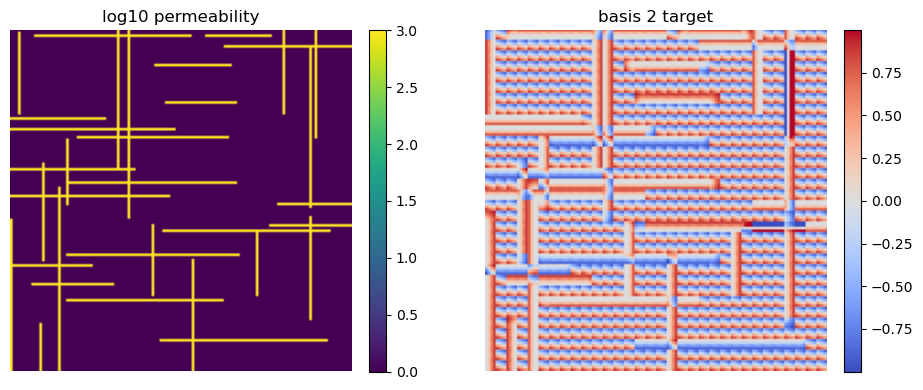

In [24]:
BASIS_INDEX = 1  # zero-based: 3 means basis function 4
BASIS_NUMBER = BASIS_INDEX + 1
plot_input_and_basis(x_all, y_all, sample_idx=0, basis_index=BASIS_INDEX)


In [25]:
train_size, val_size, test_size, batch_size, epochs = run_sizes(RUN_MODE)
BASIS_OUTPUT_DIR = RESULTS_DIR / f"basis_{BASIS_NUMBER:02d}"
BASIS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

train_loader, val_loader, test_loader = make_loaders(
    x_all,
    y_all,
    basis_index=BASIS_INDEX,
    train_size=train_size,
    val_size=val_size,
    test_size=test_size,
    batch_size=batch_size,
    seed=SEED,
)

print(f"Training basis {BASIS_NUMBER} in {RUN_MODE!r} mode")
print(f"train={train_size}, val={val_size}, test={test_size}, batch={batch_size}, epochs={epochs}")
print(f"Outputs will be saved in: {BASIS_OUTPUT_DIR.resolve()}")

model = AttentionUNet(1, 1, base_channels=32).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    epochs=epochs,
    grad_weight=GRAD_WEIGHT,
    save_path=MODEL_DIR / f"basis_{BASIS_NUMBER:02d}_best.pt",
    save=SAVE_BEST_MODEL,
    mat_save_path=BASIS_OUTPUT_DIR / f"history_basis_{BASIS_NUMBER:02d}.mat",
)


Training basis 2 in 'full' mode
train=3500, val=300, test=100, batch=32, epochs=60
Outputs will be saved in: /outputs/teaching_single_basis2_no_attention/basis_02


Epoch [1/60] | Train Loss: 0.212176, Train MSE: 0.171856, Train R2: 0.3495 | Val Loss: 0.177319, Val MSE: 0.140506, Val R2: 0.4688
Saved best model to best_model2_no_attention/basis_02_best.pt


Epoch [2/60] | Train Loss: 0.164192, Train MSE: 0.128822, Train R2: 0.5124 | Val Loss: 0.156401, Val MSE: 0.122210, Val R2: 0.5379
Saved best model to best_model2_no_attention/basis_02_best.pt


Epoch [3/60] | Train Loss: 0.143119, Train MSE: 0.110874, Train R2: 0.5804 | Val Loss: 0.136872, Val MSE: 0.105848, Val R2: 0.5997
Saved best model to best_model2_no_attention/basis_02_best.pt


Epoch [4/60] | Train Loss: 0.128871, Train MSE: 0.099136, Train R2: 0.6248 | Val Loss: 0.133215, Val MSE: 0.103440, Val R2: 0.6089
Saved best model to best_model2_no_attention/basis_02_best.pt


...

Epoch [56/60] | Train Loss: 0.011899, Train MSE: 0.009115, Train R2: 0.9655 | Val Loss: 0.030871, Val MSE: 0.024103, Val R2: 0.9090


Epoch [57/60] | Train Loss: 0.011532, Train MSE: 0.008827, Train R2: 0.9666 | Val Loss: 0.030769, Val MSE: 0.024002, Val R2: 0.9093


Epoch [58/60] | Train Loss: 0.011492, Train MSE: 0.008803, Train R2: 0.9667 | Val Loss: 0.030549, Val MSE: 0.023810, Val R2: 0.9101


Epoch [59/60] | Train Loss: 0.011239, Train MSE: 0.008604, Train R2: 0.9674 | Val Loss: 0.030309, Val MSE: 0.023634, Val R2: 0.9107
Saved best model to best_model2_no_attention/basis_02_best.pt


Epoch [60/60] | Train Loss: 0.010838, Train MSE: 0.008298, Train R2: 0.9686 | Val Loss: 0.030231, Val MSE: 0.023563, Val R2: 0.9110
Saved best model to best_model2_no_attention/basis_02_best.pt
Training history saved to outputs/teaching_single_basis2_no_attention/basis_02/history_basis_02.mat


Summary saved to outputs/teaching_single_basis2_no_attention/basis_02/summary_basis_02.json


,basis_id,mse,rmse,mae,r2,relative_l2,grad_mse,max_abs_error,n_samples
0,2,0.023456,0.153155,0.054137,0.910828,0.294048,0.06569,2.190995,100


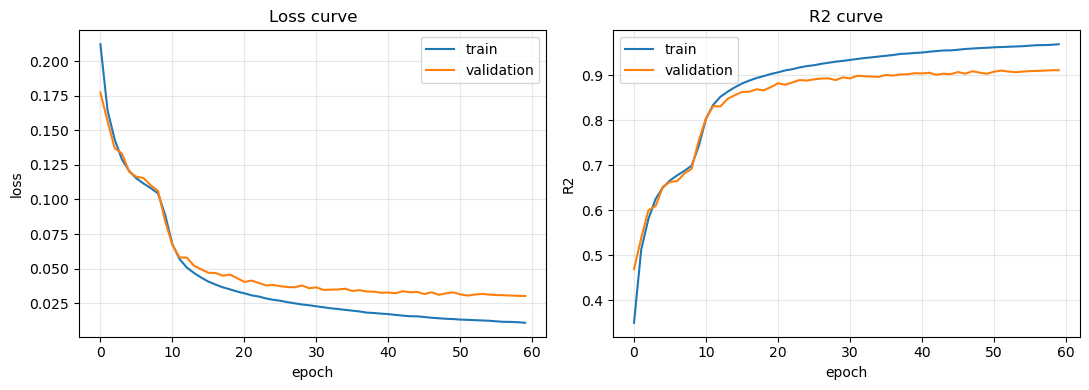

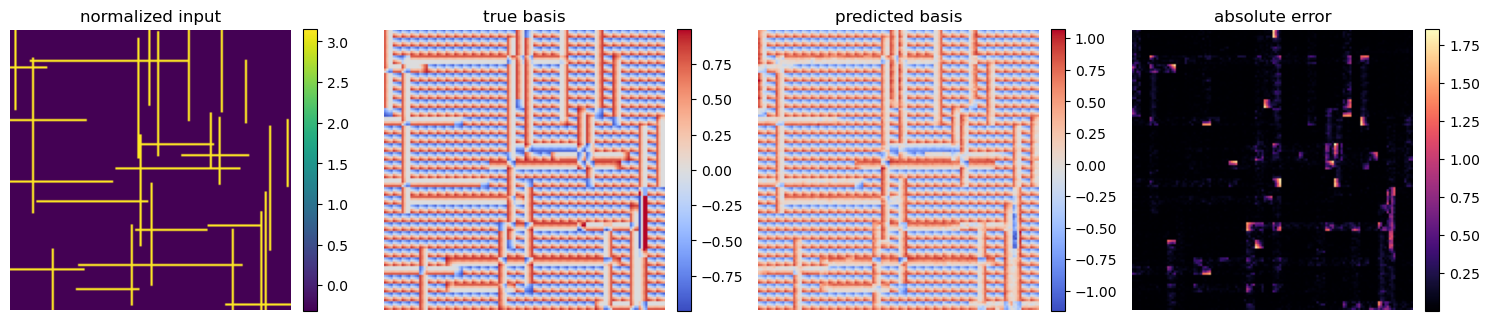

Saved outputs/teaching_single_basis2_no_attention/basis_02/basis_02_sample_00_prediction.png


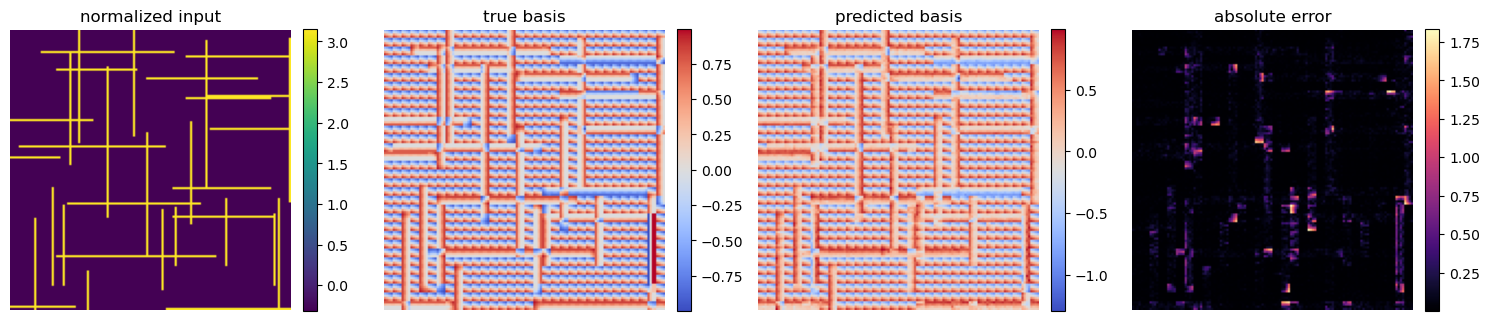

Saved outputs/teaching_single_basis2_no_attention/basis_02/basis_02_sample_01_prediction.png


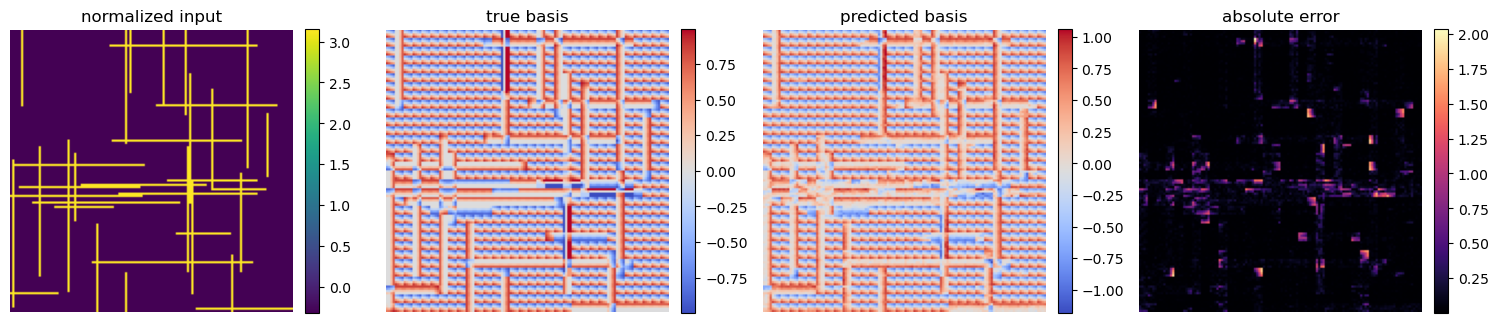

Saved outputs/teaching_single_basis2_no_attention/basis_02/basis_02_sample_02_prediction.png


In [26]:
metrics, y_true, y_pred = evaluate_model_on_loader(model, test_loader, device=device, return_predictions=True)
metrics_df = save_metrics_csv(BASIS_OUTPUT_DIR / f"metrics_basis_{BASIS_NUMBER:02d}.csv", BASIS_NUMBER, metrics)
np.savez_compressed(BASIS_OUTPUT_DIR / f"predictions_basis_{BASIS_NUMBER:02d}.npz", y_true=y_true, y_pred=y_pred)
config = {
    "run_mode": RUN_MODE,
    "seed": SEED,
    "basis_index_zero_based": BASIS_INDEX,
    "basis_number_one_based": BASIS_NUMBER,
    "train_size": train_size,
    "val_size": val_size,
    "test_size": test_size,
    "batch_size": batch_size,
    "epochs": epochs,
    "learning_rate": LEARNING_RATE,
    "grad_weight": GRAD_WEIGHT,
    "device": str(device),
}
save_summary(BASIS_OUTPUT_DIR / f"summary_basis_{BASIS_NUMBER:02d}.json", config, metrics)
display(metrics_df)
plot_history(history, save_path=BASIS_OUTPUT_DIR / f"history_basis_{BASIS_NUMBER:02d}.png")
visualize_predictions(model, test_loader, BASIS_NUMBER, BASIS_OUTPUT_DIR, device=device, num_samples=3)
